In [3]:
import pandas as pd
from torch.utils.data import DataLoader
import numpy as np 
from PIL import Image
import matplotlib.pyplot as plt

In [4]:
from torchvision.datasets import MNIST
from torchvision.transforms import transforms
transform=transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.3],[0.3])
])

In [69]:
xtr=MNIST('./data',download=True,train=True,target_transform=transform)
xter=MNIST('./data',download=False,train=False,target_transform=transform)
y=xtr.targets
xtr=xtr.data/255
yte=xter.targets
xter=xter.data/255

In [6]:
xtr[0]

tensor([[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000

tensor(5)


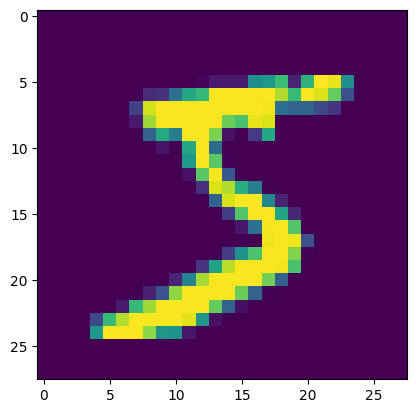

In [72]:
plt.imshow(xtr[0])
print(y[0])
newy=np.zeros((60000,10))
c=0
for i in y:
    newy[c][i]=1
    c+=1
c=0
ytest=np.zeros((10000,10))
for i in yte:
    ytest[c][i]=1
    c+=1

In [8]:
newy[0]

array([0., 0., 0., 0., 0., 1., 0., 0., 0., 0.])

In [9]:
def initialize_params(Lis):
    params={}
    for i in range(1,len(Lis)):
        params['W'+str(i)]=np.random.random((Lis[i-1],Lis[i]))
        params['b'+str(i)]=np.random.random((Lis[i],1))
    return params

In [10]:
Lis=[28*28,120,64,10]
params=initialize_params(Lis)

In [11]:
params

{'W1': array([[0.81695878, 0.01380891, 0.30762748, ..., 0.70458469, 0.70569183,
         0.33380676],
        [0.65985335, 0.99563048, 0.06999246, ..., 0.07740302, 0.62938195,
         0.90176748],
        [0.2996818 , 0.37094803, 0.47559333, ..., 0.6463058 , 0.97537689,
         0.66049746],
        ...,
        [0.41783037, 0.85082925, 0.24651521, ..., 0.87239891, 0.59037187,
         0.09431562],
        [0.34488991, 0.08717435, 0.87225751, ..., 0.23373845, 0.13870878,
         0.98511765],
        [0.50744385, 0.60655451, 0.24290675, ..., 0.71393841, 0.04879345,
         0.42218689]], shape=(784, 120)),
 'b1': array([[0.03352877],
        [0.32021675],
        [0.91540824],
        [0.22583348],
        [0.15105627],
        [0.89187367],
        [0.99591427],
        [0.64173431],
        [0.12763673],
        [0.24392275],
        [0.13856344],
        [0.31585432],
        [0.86599754],
        [0.05341028],
        [0.15048084],
        [0.00290209],
        [0.47489631],
     

In [18]:
def ReLU(k):
    for i in range(k.shape[0]):
        for j in range(k.shape[1]):
            if k[i,j]<0:
                k[i,j]=0
    return k
def softmax(k):
    nk=k-np.max(k)
    exps=np.exp(nk)
    return exps/np.sum(exps)     
def softmax_derivative(k):
    s=softmax(k).reshape(-1,1)
    return np.diagflat(s)-np.dot(s,s.T)
  

In [25]:
xtr[0]

tensor([[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000

In [15]:
def forwardr(x,w,b):
    return ReLU(np.dot(x,w)+b)
def forwards(x,w,b):
    return softmax(np.dot(x,w)+b)


In [14]:
def forward_pass(x,params,Lis):
    a=[]
    a.append(x)
    for i in range(1,len(Lis)-1):
        a.append(forwardr(a[i-1],params['W'+str(i)],params['b'+str(i)].T))
    le=len(Lis)-1
    a.append(forwards(a[le-1],params['W'+str(le)],params['b'+str(le)].T))
    return a

In [323]:
yp=forward_pass(np.array([xtr[0]]).reshape(1,-1),params,Lis)

In [304]:
def relu_derivative(a):
    return (a > 0).astype(float)

In [14]:
yp=forward_pass(np.array([x[0]]),params,Lis)
for i in yp:
    print(i.shape)
params['W3']

(1, 6)
(1, 4)
(1, 5)
(1, 1)


array([[0.1],
       [0.1],
       [0.1],
       [0.1],
       [0.1]])

In [15]:
np.dot(params['W3'],yp[1])

array([[1.82, 1.82, 1.82, 1.82],
       [1.82, 1.82, 1.82, 1.82],
       [1.82, 1.82, 1.82, 1.82],
       [1.82, 1.82, 1.82, 1.82],
       [1.82, 1.82, 1.82, 1.82]])

In [16]:
yp[1].shape,params['W2'].shape

((1, 4), (4, 5))

In [23]:
def loss_function(y_real,y_predict):
    return (y_real-y_predict)**2
def loss_function1(y_real,y_predict):
    return -np.sum(y_real*np.log(y_predict))

In [18]:
eta=2e-2

In [19]:
params['W3'].shape

(5, 1)

In [20]:
for i in params:
    print(f'{i} : {params[i].shape}')

W1 : (6, 4)
b1 : (4, 1)
W2 : (4, 5)
b2 : (5, 1)
W3 : (5, 1)
b3 : (1, 1)


In [21]:
def Update_ye(params,y,x,Lis):
    yp=forward_pass(x,params,Lis)
    params['W3']=params['W3']+(eta*2*(y[0]-yp[3][0][0])*yp[2]).T
    params['b3']=params['b3']+(eta*2*(y[0]-yp[3][0][0]))
    params['W2']=params['W2']+(eta*2*(y[0]-yp[3][0][0])*np.dot(params['W3'],yp[1])).T
    params['b2']=params['b2']+(eta*2*(y[0]-yp[3][0][0])*params['W3'])
    return params

In [23]:
params

{'W1': array([[0.1, 0.1, 0.1, 0.1],
        [0.1, 0.1, 0.1, 0.1],
        [0.1, 0.1, 0.1, 0.1],
        [0.1, 0.1, 0.1, 0.1],
        [0.1, 0.1, 0.1, 0.1],
        [0.1, 0.1, 0.1, 0.1]]),
 'b1': array([[0.],
        [0.],
        [0.],
        [0.]]),
 'W2': array([[0.1, 0.1, 0.1, 0.1, 0.1],
        [0.1, 0.1, 0.1, 0.1, 0.1],
        [0.1, 0.1, 0.1, 0.1, 0.1],
        [0.1, 0.1, 0.1, 0.1, 0.1]]),
 'b2': array([[0.],
        [0.],
        [0.],
        [0.],
        [0.]]),
 'W3': array([[0.1],
        [0.1],
        [0.1],
        [0.1],
        [0.1]]),
 'b3': array([[0.]])}

In [61]:
relu_derivative(yp[2])

array([[1., 1., 1., 1., 1.]])

In [365]:
yp[3][0].shape,newy[0].shape

((10,), (10,))

In [12]:
def relu_derivative(a):
    return (a > 0).astype(float)

def update(params, x, y, eta, Lis):

    yp = forward_pass(x, params, Lis)
    a0 = yp[0]      # Input layer (1, 784)
    a1 = yp[1]      # Hidden 1    (1, 120)
    a2 = yp[2]      # Hidden 2    (1, 64)
    y_hat = yp[3]   # Output layer(1, 10)
    
    # 1. Correct gradient for Softmax + Categorical Cross-Entropy
    # 'y' must be a one-hot encoded vector of shape (1, 10)
    delta3 = y_hat - y                 
    
    # 2. Changed '*' to '@' for correct matrix multiplication
    dW3 = a2.T @ delta3                
    db3 = delta3                       
    
    delta2 = (delta3 @ params['W3'].T) * relu_derivative(a2)
    dW2 = a1.T @ delta2                
    db2 = delta2                       

    delta1 = (delta2 @ params['W2'].T) * relu_derivative(a1)
    dW1 = a0.T @ delta1                
    db1 = delta1                       

    # 3. Changed '+=' to '-=' to minimize loss via Gradient Descent
    params['W3'] -= eta * dW3
    params['b3'] -= eta * db3.reshape(params['b3'].shape)

    params['W2'] -= eta * dW2
    params['b2'] -= eta * db2.reshape(params['b2'].shape)

    params['W1'] -= eta * dW1
    params['b1'] -= eta * db1.reshape(params['b1'].shape)
    
    return params


In [25]:
update(params,np.array([x[0]]),y[0],eta,Lis)

{'W1': array([[0.190752, 0.190752, 0.190752, 0.190752],
        [0.29852 , 0.29852 , 0.29852 , 0.29852 ],
        [2.936   , 2.936   , 2.936   , 2.936   ],
        [2.0852  , 2.0852  , 2.0852  , 2.0852  ],
        [0.1     , 0.1     , 0.1     , 0.1     ],
        [0.151048, 0.151048, 0.151048, 0.151048]]),
 'b1': array([[0.02836],
        [0.02836],
        [0.02836],
        [0.02836]]),
 'W2': array([[1.132304, 1.132304, 1.132304, 1.132304, 1.132304],
        [1.132304, 1.132304, 1.132304, 1.132304, 1.132304],
        [1.132304, 1.132304, 1.132304, 1.132304, 1.132304],
        [1.132304, 1.132304, 1.132304, 1.132304, 1.132304]]),
 'b2': array([[0.05672],
        [0.05672],
        [0.05672],
        [0.05672],
        [0.05672]]),
 'W3': array([[4.229216],
        [4.229216],
        [4.229216],
        [4.229216],
        [4.229216]]),
 'b3': array([[0.5672]])}

In [30]:
loss_function(yp[3][0][0],y[0])

np.float64(804.2896)

In [77]:
eta=1e-5

In [183]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
xt=scaler.fit_transform(x)

In [59]:
params=initialize_params(Lis)

In [319]:
xtr.shape[0]

60000

In [61]:
def categorical_cross_entropy(y_hat, y):
    epsilon = 1e-15
    y_hat = np.clip(y_hat, epsilon, 1.0 - epsilon)
    loss = -np.sum(y * np.log(y_hat), axis=-1)
    return np.mean(loss)

In [81]:
epoch=10
for j in range(epoch):
    total_loss=0
    for i in range(xtr.shape[0]):
        yp=forward_pass(np.array([xtr[i]]).reshape(1,-1),params,Lis)
        update(params,np.array([xtr[i]]).reshape(1,-1),newy[i],eta,Lis)
        loss=categorical_cross_entropy(newy[i],yp[3][0])
        total_loss+=loss
    print(f'MSE for the {j}th Pass :',total_loss)

MSE for the 0th Pass : 259470.00898050712
MSE for the 1th Pass : 259236.34417728995
MSE for the 2th Pass : 258948.57739704495
MSE for the 3th Pass : 258730.93679202598
MSE for the 4th Pass : 258514.65763985028
MSE for the 5th Pass : 258213.66896805563
MSE for the 6th Pass : 257896.35384794377
MSE for the 7th Pass : 257604.28165074802
MSE for the 8th Pass : 257360.29724440002
MSE for the 9th Pass : 257067.458019249


In [83]:
c=0
for p in range(10000):
    yp=forward_pass(np.array([xter[p]]).reshape(1,-1),params,Lis)
    if np.argmax(yp[3][0])!=np.argmax(ytest[p]):
        print(np.argmax(yp[3][0]),np.argmax(ytest[p]),p)
        c+=1
print(c)

6 5 8
0 4 33
3 2 38
1 3 44
4 9 62
3 2 72
5 9 104
8 2 119
8 4 121
4 7 124
8 2 149
3 2 172
3 5 187
3 9 193
5 6 217
9 8 233
5 9 241
5 3 245
8 4 247
9 4 250
0 6 259
3 5 261
2 7 282
3 2 291
1 4 300
5 0 305
9 7 307
7 9 320
7 2 321
9 0 324
3 5 340
4 6 341
0 5 352
7 2 362
8 6 366
9 4 376
7 3 381
5 6 386
9 8 403
3 5 412
4 5 433
8 2 444
0 6 445
9 4 447
8 9 448
5 6 457
7 3 464
3 9 479
2 8 495
3 5 502
5 3 507
5 4 511
8 3 515
1 3 531
3 8 543
8 2 547
9 7 550
1 7 551
6 8 553
9 4 565
2 3 578
3 8 591
6 4 610
4 9 627
9 2 659
2 7 684
3 8 691
9 4 707
6 0 717
8 5 720
8 2 728
8 2 738
9 4 740
8 2 741
9 4 760
5 8 781
1 3 795
0 2 823
3 8 839
7 8 844
3 5 857
6 8 877
9 4 881
7 9 882
2 7 898
7 2 924
5 3 938
0 2 939
2 7 950
0 6 965
2 3 982
3 5 1003
9 7 1012
0 6 1014
8 5 1032
9 7 1039
8 6 1044
4 8 1068
8 5 1073
3 5 1082
0 5 1089
9 7 1096
3 8 1101
3 9 1107
6 4 1112
8 3 1114
2 7 1119
9 8 1125
7 3 1128
3 5 1135
7 9 1152
9 4 1157
9 7 1173
1 6 1181
1 2 1184
4 9 1192
9 7 1194
4 8 1198
3 8 1200
5 8 1202
8 3 1204
1 7 1206
